In [37]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # "lithium plating": "partially reversible",
options = {"thermal": "lumped","lithium plating": "partially reversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"} #"lithium plating": "irreversible",



In [38]:
model = pybamm.lithium_ion.SPM(options=options) #DFN or SPM

In [39]:
# %load nialldata_tuneparameters_final.py
#For tuning with base heat cooling for Niall data only
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                         
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius
parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 5*1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 42000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.4,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 2*0.25*0.5*1.5*0.1/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 2*0.13*0.5*1.5*0.1/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.3,
                         "Negative electrode LAM constant exponential term": 2.3,
                         
                         })






#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 300*5*1e-09*0.001,
                        "Lithium plating transfer coefficient": 0.65,
                        "Dead lithium decay constant [s-1]": 7e-05,
                        
                        })

In [40]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [41]:
experiment0 = pybamm.Experiment(
    [
        (
            "Charge at 0.33C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
            "Rest for 10 min (1 minute period)",
            "Discharge at 0.33C until 2.85 V",
            "Rest for 20 min (1 minute period)",
        )    
    ]
    * 2000,
    termination= "80% capacity"
)

In [42]:
from itertools import product


temp_list = [10, 25, 40] #25,


all_cases = list(product(temp_list))

df = pd.DataFrame(all_cases,columns = ["Temperature"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/Cases_std_cycle_500.csv", index=False)

Cycling:  27%|██▋       | 543/2000 [00:44<01:58, 12.33it/s]


Took 25.924 s


Cycling:  36%|███▋      | 726/2000 [01:02<01:49, 11.63it/s]


Took 38.846 s


Cycling:  21%|██        | 422/2000 [00:36<02:17, 11.45it/s]


Took 23.602 s


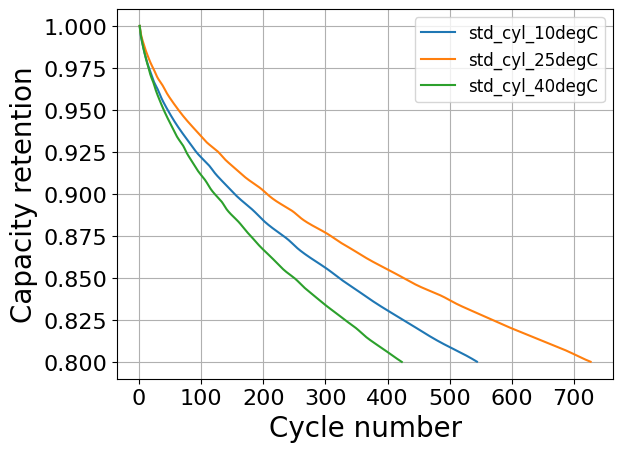

In [43]:

safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 50, "max_error_test_failures": 20,"max_convergence_failures": 200,}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

for n in range(3): #range(len(df)): 
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})
    
    sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']

    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Cycle number"] =cycle1
    df2["Capacity Retention"] = Q1/Q1[0]
    df2["LAMpe_per"] =mlam_p
    df2["LAMne_per"] =mlam_n
    df2["Qsei"] = Qsei
    df2["Qpl"] = Qpl
    df2["LLIp"] = Qlli
    df2["Qside"] = Qside


    df2.to_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/rev1_Case{simcase}_{tempC_case}degC_std_cycle_500_DFN.csv")

    plt.plot(cycle1,Q1/Q1[0], label =f"std_cyl_{tempC_case}degC")  
    plt.legend(fontsize=12)

plt.xlabel("Cycle number", fontsize =20)
plt.ylabel("Capacity retention", fontsize =20)
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.grid(True)
plt.show()

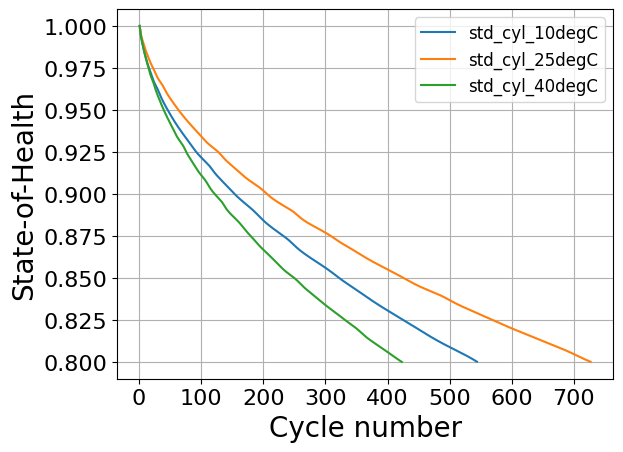

In [48]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/Cases_std_cycle_500.csv")
cycles_per_day =1

for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/rev1_Case{simcase}_{tempC_case}degC_std_cycle_500_DFN.csv")
    plt.plot(df4["Cycle number"],df4["Capacity Retention"], label =f"std_cyl_{tempC_case}degC")  #_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=12)

plt.xlabel("Cycle number", fontsize =20)
plt.ylabel("State-of-Health", fontsize =20)
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.grid(True)
plt.show()    
    

In [208]:
# safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,

# parameter_values.update({"Ambient temperature [K]": 273.15+40,
#                         "Initial temperature [K]": 273.15+40 })

# sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver) #
# sol1 = sim1.solve(showprogress=True)
# print("Took", sol1.solve_time)



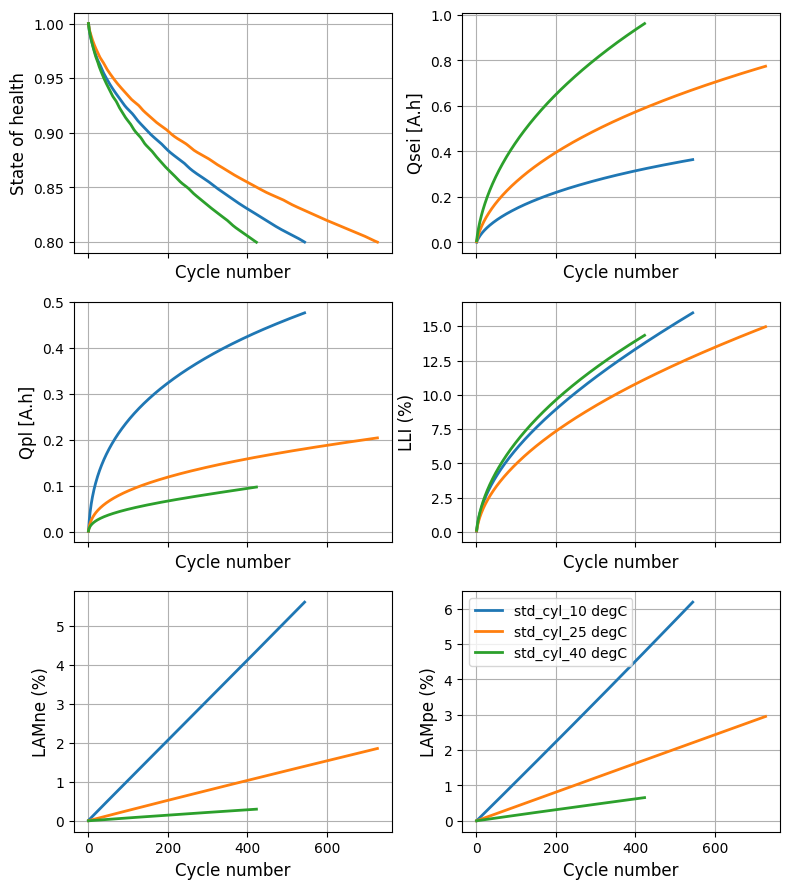

In [49]:
df3 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/Cases_std_cycle_500.csv")
cycles_per_day =1


fig, axes = plt.subplots(3, 2, figsize=(8,9), sharex=True)
axes = axes.flatten()
for m in range(3):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    # dod_case = df3["DoD"][n]*0.01
    # soc_case = df3["SoC"][n]*0.01
    # crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/rev1LinkingPaper2026/stdCyclingStudies/rev1_Case{simcase}_{tempC_case}degC_std_cycle_500_DFN.csv")
    
    xcycle = df4["Cycle number"]
    
    variables = ["Capacity Retention",  "Qsei", "Qpl", "LLIp","LAMne_per", "LAMpe_per",   ]
    variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LLI (%)", "LAMne (%)", "LAMpe (%)",   ] #"Qside",

    
    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"std_cyl_{tempC_case} degC", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Cycle number", fontsize=12) 
        axes[i].grid(True)
    axes[i].legend()
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [45]:
model.variable_names()

['Time [s]',
 'Time [min]',
 'Time [h]',
 'x [m]',
 'x_n [m]',
 'x_s [m]',
 'x_p [m]',
 'r_n [m]',
 'r_p [m]',
 'Current variable [A]',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Throughput capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Negative electrode interface utilisation variable',
 'X-averaged negative electrode interface utilisation variable',
 'Negative electrode interface utilisation',
 'X-averaged negative electrode interface utilisation',
 'Positive electrode interface utilisation variable',
 'X-averaged positive electrode interface utilisation variable',
 'Positive electrode interface utilisation',
 'X-averaged positive electrode interface utilisation',
 'Negative particle crack length [m]',
 'X-averaged negative particle crack length [m]',
 'Negative particle cracking rate [m.s-1]',
 'X-averaged negative particle cracking rate [m.s-1]',
 'Positive particle crack length [m]',
 'X-averaged positive 

In [46]:
sim1.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=2523.9120101704607, step=25.239120101704607)…